<a href="https://colab.research.google.com/github/MMujtabaX/Pakistan-Real-Estate-EDA/blob/main/EDA_Portfolio_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PAKISTAN REAL MARKET ANALYSIS**

Phase 1: Import Libraries and Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_rows', None)


In [ ]:
pd.reset_option('display.max_rows')


In [ ]:
url = "https://docs.google.com/spreadsheets/d/10S_5UxUuqOHAxzjf5PNxE2nmax2fSo7oSyh48K4fVw8/export?format=csv"
data = pd.read_csv(url,
                   names = ['property_id', 'location_id', 'page_url', 'property_type', 'price', 'location', 'city', 'province_name', 'latitude', 'longitude',
                                 'baths', 'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent'],
                   header = 0,
                   parse_dates = ['date_added'],
                   date_format = "mixed")


In [ ]:
data.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,2019-07-17,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,2018-10-06,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,2019-07-03,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,2019-04-04,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,2019-04-04,NaN,NaN


In [ ]:
data.tail()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
191388,17468383,174,https://www.zameen.com/Property/islamabad_i_8_...,Upper Portion,70000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,3,2019-07-24,Property World,Zafran
191389,17468384,174,https://www.zameen.com/Property/islamabad_i_8_...,Upper Portion,40000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,2,2019-07-24,Property World,Zafran
191390,17468482,167,https://www.zameen.com/Property/islamabad_g_10...,House,160000,G-10,Islamabad,Islamabad Capital,33.676104,73.013842,6,1 Kanal,For Rent,6,2019-07-24,Azaan Associates,Usman Rehman
191391,17468586,339,https://www.zameen.com/Property/dha_defence_dh...,Flat,25000,DHA Defence,Islamabad,Islamabad Capital,33.527944,73.161392,2,2.7 Marla,For Rent,2,2019-07-24,New National Properties,TALHA MIAN AHMAD
191392,17468660,3421,https://www.zameen.com/Property/i_10_i_10_2_i_...,Upper Portion,26000,I-10,Islamabad,Islamabad Capital,33.649779,73.029385,1,0 Marla,For Rent,3,2019-07-24,Select Homes,"Qaiser Shahzad, Chaudhary Waseem"


In [ ]:
data.shape

(191393, 17)

In [ ]:
i = 0
for col in data:
  print("Name of the feature is: ", col)
  i += 1
print("\nTotal number of feature is: ", i)

Name of the feature is:  property_id
Name of the feature is:  location_id
Name of the feature is:  page_url
Name of the feature is:  property_type
Name of the feature is:  price
Name of the feature is:  location
Name of the feature is:  city
Name of the feature is:  province_name
Name of the feature is:  latitude
Name of the feature is:  longitude
Name of the feature is:  baths
Name of the feature is:  area
Name of the feature is:  purpose
Name of the feature is:  bedrooms
Name of the feature is:  date_added
Name of the feature is:  agency
Name of the feature is:  agent

Total number of feature is:  17


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191393 entries, 0 to 191392
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   property_id    191393 non-null  int64         
 1   location_id    191393 non-null  int64         
 2   page_url       191393 non-null  object        
 3   property_type  191393 non-null  object        
 4   price          191393 non-null  int64         
 5   location       191393 non-null  object        
 6   city           191393 non-null  object        
 7   province_name  191393 non-null  object        
 8   latitude       191393 non-null  float64       
 9   longitude      191393 non-null  float64       
 10  baths          191393 non-null  int64         
 11  area           191393 non-null  object        
 12  purpose        191393 non-null  object        
 13  bedrooms       191393 non-null  int64         
 14  date_added     191393 non-null  datetime64[ns]
 15  

In [ ]:
data.describe(include = 'all')

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
count,1.913930e+05,191393.000000,191393,191393,1.913930e+05,191393,191393,191393,191393.000000,191393.000000,191393.000000,191393,191393,191393.000000,191393,144014,144013
unique,NaN,NaN,191393,7,NaN,1536,5,3,NaN,NaN,NaN,352,2,NaN,NaN,5923,11352
top,NaN,NaN,https://www.zameen.com/Property/i_10_i_10_2_i_...,House,NaN,DHA Defence,Karachi,Punjab,NaN,NaN,NaN,1 Kanal,For Sale,NaN,NaN,Mash Allah Estate & Builders,Azam Ali
freq,NaN,NaN,1,118915,NaN,26161,60484,90714,NaN,NaN,NaN,25452,127018,NaN,NaN,821,797
mean,1.573170e+07,4224.580350,NaN,NaN,1.644655e+07,NaN,NaN,NaN,30.104593,71.572992,2.865956,NaN,NaN,3.171516,2019-05-27 04:10:13.564759296,NaN,NaN
min,8.657500e+04,1.000000,NaN,NaN,0.000000e+00,NaN,NaN,NaN,11.052446,25.906027,0.000000,NaN,NaN,0.000000,2018-08-05 00:00:00,NaN,NaN
25%,1.511867e+07,1057.000000,NaN,NaN,8.000000e+04,NaN,NaN,NaN,24.972287,67.152597,0.000000,NaN,NaN,2.000000,2019-05-06 00:00:00,NaN,NaN
50%,1.676385e+07,3233.000000,NaN,NaN,7.300000e+06,NaN,NaN,NaN,31.463563,73.077743,3.000000,NaN,NaN,3.000000,2019-06-28 00:00:00,NaN,NaN
75%,1.715282e+07,7182.000000,NaN,NaN,1.800000e+07,NaN,NaN,NaN,33.550869,74.228218,4.000000,NaN,NaN,4.000000,2019-07-10 00:00:00,NaN,NaN
max,1.769386e+07,14246.000000,NaN,NaN,2.000000e+09,NaN,NaN,NaN,73.184088,80.161430,403.000000,NaN,NaN,68.000000,2019-08-06 00:00:00,NaN,NaN


Phase 2: Data Cleaning and Preparation

In [ ]:
data.isnull()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191388,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
191389,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
191390,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
191391,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
null_count = data.isnull().sum()
null_count

,0
property_id,0
location_id,0
page_url,0
property_type,0
price,0
location,0
city,0
province_name,0
latitude,0
longitude,0


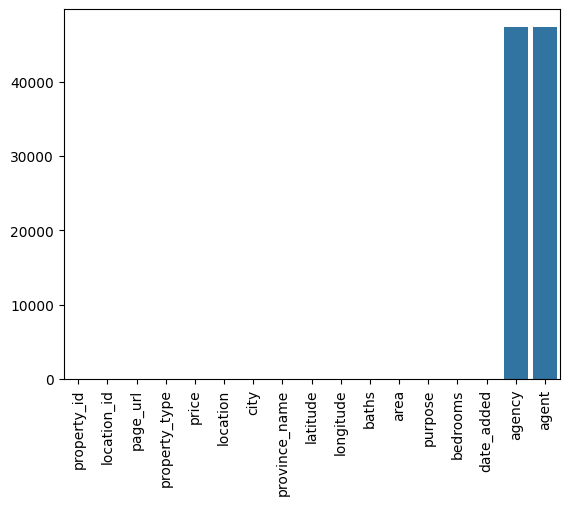

In [ ]:
sns.barplot(null_count)
plt.xticks(rotation = 90)
plt.show()

In [ ]:
null_count.sort_values(ascending = False).head(2)

,0
agent,47380
agency,47379


In [ ]:
data = data.drop(columns = ['property_id', 'location_id', 'page_url', 'latitude', 'longitude'])

In [ ]:
data.head()

,property_type,price,location,city,province_name,baths,area,purpose,bedrooms,date_added,agency,agent
0,House,220000000,Model Town,Lahore,Punjab,0,6 Kanal,For Sale,0,2019-07-17,Real Biz International,Usama Khan
1,House,40000000,Multan Road,Lahore,Punjab,5,1 Kanal,For Sale,5,2018-10-06,Khan Estate,mohsinkhan and B
2,House,9500000,Eden,Lahore,Punjab,0,9 Marla,For Sale,3,2019-07-03,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,House,125000000,Gulberg,Lahore,Punjab,7,1 Kanal,For Sale,8,2019-04-04,NaN,NaN
4,House,21000000,Allama Iqbal Town,Lahore,Punjab,5,11 Marla,For Sale,6,2019-04-04,NaN,NaN


In [ ]:
data.loc[:, 'agency'] = data['agency'].fillna('Unknown')
data.loc[:, 'agent'] = data['agent'].fillna('Unknown')

In [ ]:
data.isnull().sum()

,0
property_type,0
price,0
location,0
city,0
province_name,0
baths,0
area,0
purpose,0
bedrooms,0
date_added,0


In [ ]:
def get_area(x):
  x = x.replace(",", "")
  if (x.split(" ")[1] == 'Kanal'):
    return (float(x.split(" ")[0]) * 20)
  else:
    return float(x.split(" ")[0])

data["area_in_marla"] = data["area"].transform(get_area)


In [ ]:
data.head()

,property_type,price,location,city,province_name,baths,area,purpose,bedrooms,date_added,agency,agent,area_in_marla
0,House,220000000,Model Town,Lahore,Punjab,0,6 Kanal,For Sale,0,2019-07-17,Real Biz International,Usama Khan,120.0
1,House,40000000,Multan Road,Lahore,Punjab,5,1 Kanal,For Sale,5,2018-10-06,Khan Estate,mohsinkhan and B,20.0
2,House,9500000,Eden,Lahore,Punjab,0,9 Marla,For Sale,3,2019-07-03,Shahum Estate 2,"Babar Hameed, Raja Omar",9.0
3,House,125000000,Gulberg,Lahore,Punjab,7,1 Kanal,For Sale,8,2019-04-04,Unknown,Unknown,20.0
4,House,21000000,Allama Iqbal Town,Lahore,Punjab,5,11 Marla,For Sale,6,2019-04-04,Unknown,Unknown,11.0


Phase 3: Outlier Detection

<Axes: xlabel='price'>

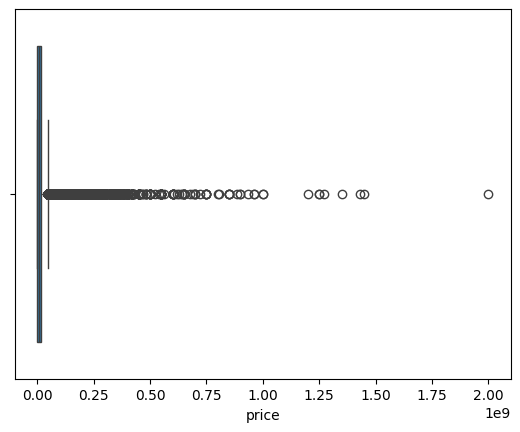

In [ ]:
sns.boxplot(x = data["price"])

<Axes: xlabel='area_in_marla'>

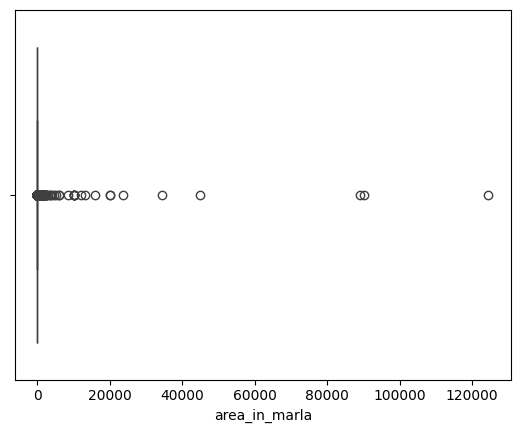

In [ ]:
sns.boxplot(x = data["area_in_marla"])

<Axes: xlabel='price', ylabel='area_in_marla'>

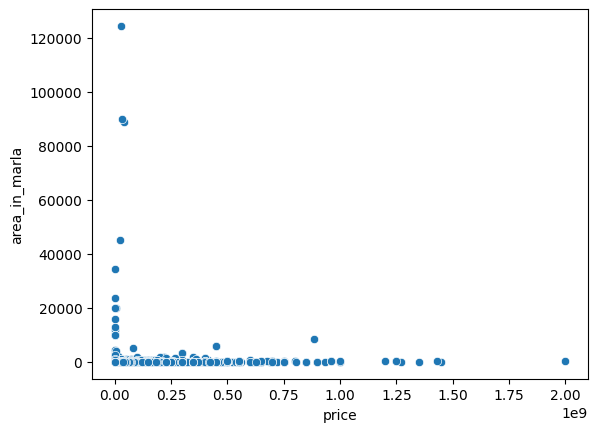

In [ ]:
sns.scatterplot(x = data["price"], y = data["area_in_marla"])

In [ ]:
data[["price", "area_in_marla"]].describe()

,price,area_in_marla
count,1.913930e+05,191393.000000
mean,1.644655e+07,14.573527
std,3.416412e+07,443.343252
min,0.000000e+00,0.000000
25%,8.000000e+04,4.900000
50%,7.300000e+06,7.600000
75%,1.800000e+07,12.000000
max,2.000000e+09,124444.000000


In [ ]:
print("Price skew:", data['price'].skew())
print("Area skew:", data['area_in_marla'].skew())


Price skew: 9.513942667468175
Area skew: 212.02262972252268


In [ ]:
q1 = data["price"].quantile(0.25)
q3 = data["price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
data[~((data["price"] >= lower_bound) & (data["price"] <= upper_bound))]

,property_type,price,location,city,province_name,baths,area,purpose,bedrooms,date_added,agency,agent,area_in_marla
0,House,220000000,Model Town,Lahore,Punjab,0,6 Kanal,For Sale,0,2019-07-17,Real Biz International,Usama Khan,120.0
3,House,125000000,Gulberg,Lahore,Punjab,7,1 Kanal,For Sale,8,2019-04-04,Unknown,Unknown,20.0
5,House,52000000,Gulberg,Lahore,Punjab,6,1 Kanal,For Sale,5,2019-06-02,MATZ Services,Group Captain (R) Tajammul Baig,20.0
11,House,87500000,Upper Mall,Lahore,Punjab,5,1.2 Kanal,For Sale,4,2019-06-30,Hamza Real Estate,Imran Shahad,24.0
17,House,50000000,Agrics Town,Lahore,Punjab,7,18 Marla,For Sale,6,2019-07-10,Unknown,Unknown,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
190912,House,47500000,DHA Defence,Lahore,Punjab,6,1 Kanal,For Sale,5,2019-08-06,Unknown,Unknown,20.0
190913,Farm House,64500000,Bedian Road,Lahore,Punjab,6,4 Kanal,For Sale,5,2019-08-06,Unknown,Unknown,80.0
190928,House,150000000,Gulberg,Lahore,Punjab,4,2 Kanal,For Sale,4,2019-08-06,Chohan Estate DHA,Aqib Hameed,40.0
190929,House,48500000,DHA Defence,Lahore,Punjab,6,1 Kanal,For Sale,5,2019-08-06,Summit Estate,Seinum Qureshi,20.0


In [ ]:
Q1 = data["area_in_marla"].quantile(0.25)
Q3 = data["area_in_marla"].quantile(0.75)
IQR = Q3 - Q1
Lower_bound = Q1 - (1.5 * IQR)
Upper_bound = Q3 + (1.5 * IQR)
data[~((data["area_in_marla"] >= Lower_bound) & (data["area_in_marla"] <= Upper_bound))]

,property_type,price,location,city,province_name,baths,area,purpose,bedrooms,date_added,agency,agent,area_in_marla
0,House,220000000,Model Town,Lahore,Punjab,0,6 Kanal,For Sale,0,2019-07-17,Real Biz International,Usama Khan,120.0
9,House,40000000,Izmir Town,Lahore,Punjab,0,1.6 Kanal,For Sale,6,2019-07-03,Sukhera Estate & Builders,Ahmed Sheraz Sukhera,32.0
11,House,87500000,Upper Mall,Lahore,Punjab,5,1.2 Kanal,For Sale,4,2019-06-30,Hamza Real Estate,Imran Shahad,24.0
34,House,620000000,GOR,Lahore,Punjab,8,6.5 Kanal,For Sale,8,2019-05-03,Punjaab Estates,Irfan Rehman Khan,130.0
38,House,65000000,Valencia Housing Society,Lahore,Punjab,0,2 Kanal,For Sale,0,2019-06-02,Punjaab Estates,Irfan Rehman Khan,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
191359,House,1800000,F-8,Islamabad,Islamabad Capital,10,2 Kanal,For Rent,10,2019-07-24,5 Zones Associates,Muhammad Imran,40.0
191360,Upper Portion,250000,F-8,Islamabad,Islamabad Capital,3,2 Kanal,For Rent,3,2019-07-24,5 Zones Associates,Muhammad Imran,40.0
191361,House,400000,F-7,Islamabad,Islamabad Capital,6,1.2 Kanal,For Rent,5,2019-07-24,Professional Estate Managers,"Rana Muhammad Abbas, Rana Mussyeb Ali Khan",24.0
191367,House,15000,E-11,Islamabad,Islamabad Capital,1,40 Kanal,For Rent,1,2019-07-24,HA Real Estate,"Muhammad Ayaz Khan, Hazrat Khattak",800.0


**Phase 4: Exploratory Data Analysis (EDA)**

A. Univariate Analysis (One Variable)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


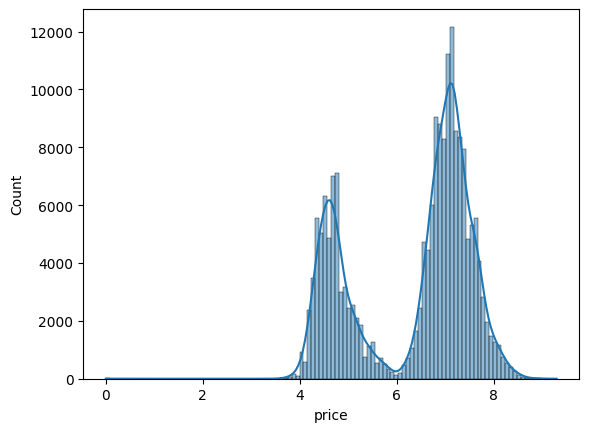

,price
count,1.913930e+05
mean,1.644655e+07
std,3.416412e+07
min,0.000000e+00
25%,8.000000e+04
50%,7.300000e+06
75%,1.800000e+07
max,2.000000e+09


In [ ]:
sns.histplot(np.log10(data['price']), kde=True)
plt.show()
data["price"].describe()

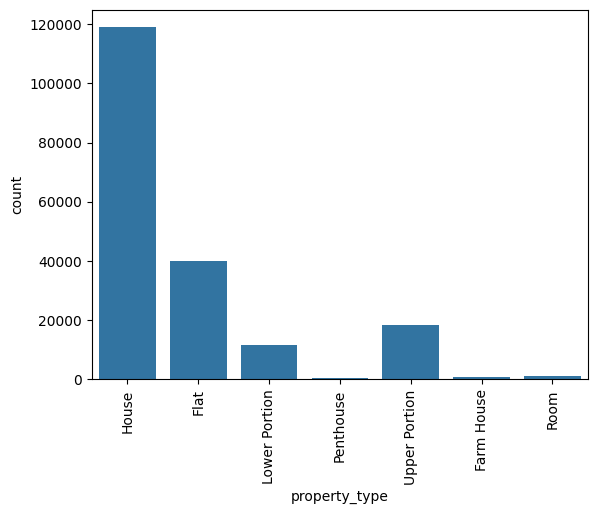

In [ ]:
sns.countplot(x = data["property_type"])
plt.xticks(rotation = 90)
plt.show()

In [ ]:
top_cities = data["city"].value_counts()[:5]
top_cities

,count
city,
Karachi,60484
Lahore,58736
Islamabad,40195
Rawalpindi,22898
Faisalabad,9080


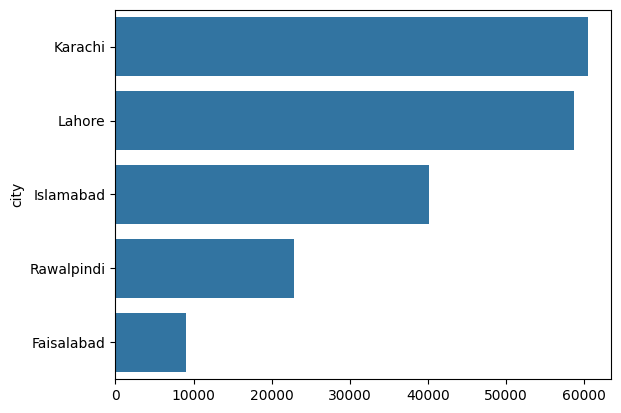

In [ ]:
sns.barplot(x = top_cities.values, y = top_cities.index)
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


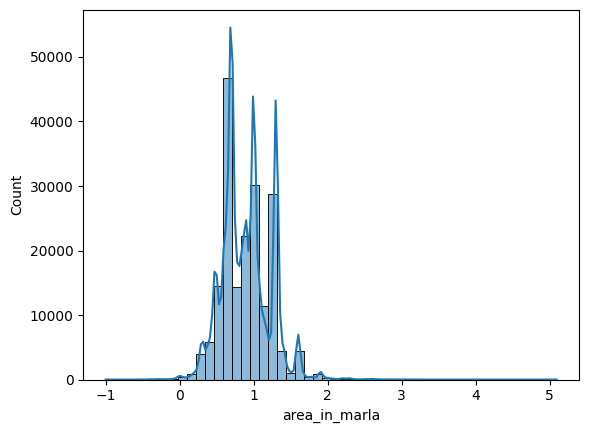

,area_in_marla
count,191393.000000
mean,14.573527
std,443.343252
min,0.000000
25%,4.900000
50%,7.600000
75%,12.000000
max,124444.000000


In [ ]:
sns.histplot(np.log10(data["area_in_marla"]), bins = 50, kde=True)
plt.show()
data["area_in_marla"].describe()


B. Bivariate Analysis (Two Variables)

In [ ]:
city_plot = data["city"].value_counts()[:3].index
city_plot_data = data[data["city"].isin(city_plot)]

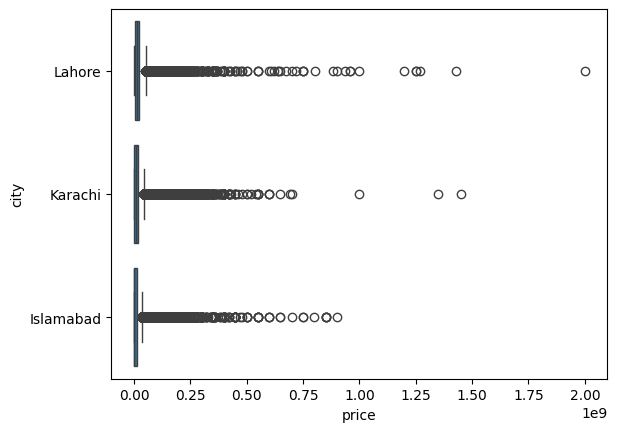

In [ ]:
sns.boxplot(data = city_plot_data, x = 'price', y = 'city')
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


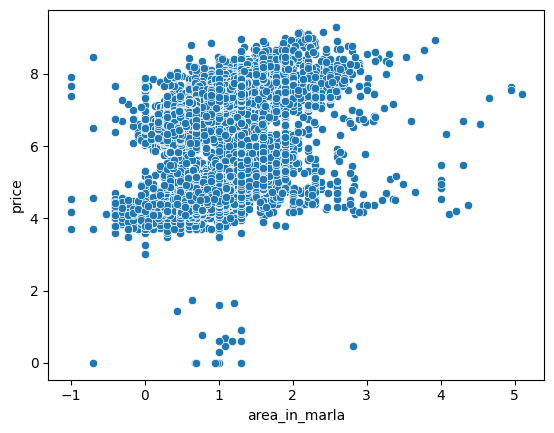

In [ ]:
sns.scatterplot(x = np.log10(data['area_in_marla']), y = np.log10(data['price']))
plt.show()

In [ ]:
data[['area_in_marla','price']].corr()


,area_in_marla,price
area_in_marla,1.000000,0.021809
price,0.021809,1.000000


In [ ]:
small_area = data["area_in_marla"].quantile(0.1)
large_price = data["price"].quantile(0.9)
anomaly = data[(data["area_in_marla"] < small_area) & (data["price"] > large_price)]
anomaly[["location", "city", "province_name"]]

,location,city,province_name
15626,Walled City,Lahore,Punjab
59640,Landhi,Karachi,Sindh
64620,Bahria Town,Islamabad,Islamabad Capital
66160,Sant Nagar,Lahore,Punjab
84131,DHA Defence,Lahore,Punjab
90970,DHA Defence,Karachi,Sindh
103354,F-8,Islamabad,Islamabad Capital
120663,Gulshan-e-Iqbal Town,Karachi,Sindh
128728,Bahria Town,Lahore,Punjab
135319,DHA Defence,Lahore,Punjab


In [ ]:
data['baths'].unique()

array([  0,   5,   7,   6,   4,   3,   2,   8,   1,  10,   9,  11,  13,
        12, 403,  14,  15])

In [ ]:
imputed_baths = data[(data["baths"] >= 1) & (data["baths"] <= 15)]

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='baths', ylabel='price'>

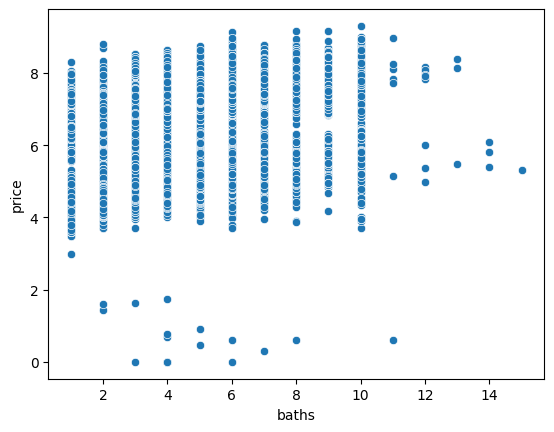

In [ ]:
sns.scatterplot(data = imputed_baths, x = 'baths', y = np.log10(data['price']))

In [ ]:
year = data["date_added"].dt.year
year

,date_added
0,2019
1,2018
2,2019
3,2019
4,2019
...,...
191388,2019
191389,2019
191390,2019
191391,2019


In [ ]:
year_counts = data['date_added'].value_counts().sort_index()


<Axes: xlabel='date_added', ylabel='count'>

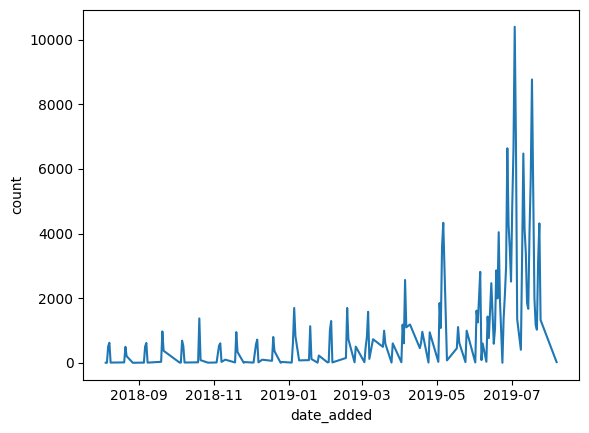

In [ ]:
sns.lineplot(year_counts)

C. Multivariate Analysis (Three+ Variables)

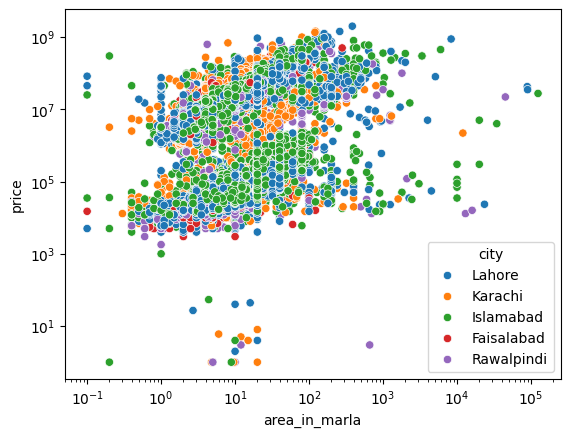

In [ ]:
sns.scatterplot(
    data=data,
    x='area_in_marla',
    y='price',
    hue='city')
plt.xscale('log')
plt.yscale('log')
plt.show()

<Axes: >

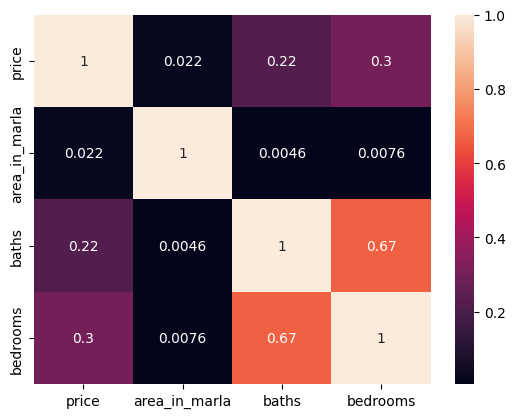

In [ ]:
correlation_matrix = data[["price", "area_in_marla", "baths", "bedrooms"]].corr()
sns.heatmap(correlation_matrix, annot = True)

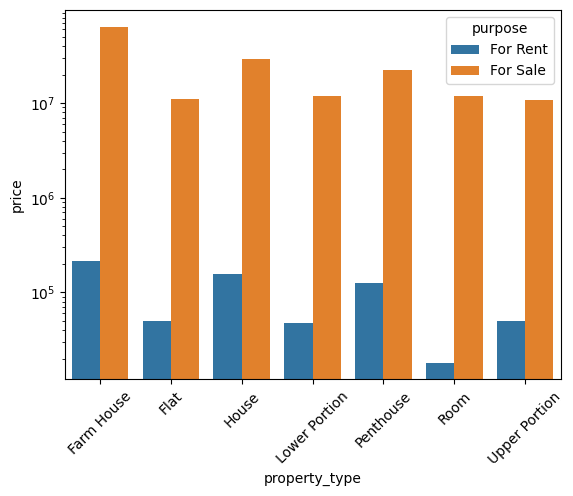

In [ ]:
from pandas._libs.tslibs.offsets import roll_qtrday
avg_price = data.groupby(['property_type', 'purpose'])['price'].mean().reset_index()
sns.barplot(data = avg_price, x = 'property_type', y = 'price', hue = 'purpose')
plt.xticks(rotation = 45)
plt.yscale('log')
plt.show()


**Phase 5: Business Questions (Q&A)**

In [ ]:
high_value_threshold = 50000000
high_value = data[data['price'] > high_value_threshold]
high_value['year'] = high_value['date_added'].dt.year
city_year_counts = high_value.groupby(['city','year']).size().reset_index(name='count')
city_year_counts.head()




/tmp/ipython-input-3335982170.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_value['year'] = high_value['date_added'].dt.year


,city,year,count
0,Faisalabad,2018,9
1,Faisalabad,2019,154
2,Islamabad,2018,122
3,Islamabad,2019,2362
4,Karachi,2018,301


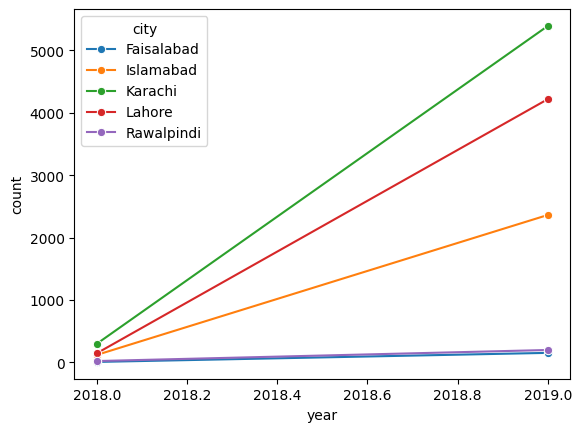

In [ ]:
sns.lineplot(data=city_year_counts, x='year', y='count', hue='city', marker='o')
plt.show()

In [ ]:
data['year'] = data['date_added'].dt.year

city_year_type = data.groupby(['city', 'year', 'property_type']).size().reset_index(name='count')
city_year_type


,city,year,property_type,count
0,Faisalabad,2018,Flat,10
1,Faisalabad,2018,House,648
2,Faisalabad,2018,Lower Portion,21
3,Faisalabad,2018,Penthouse,2
4,Faisalabad,2018,Room,10
...,...,...,...,...
62,Rawalpindi,2019,House,14144
63,Rawalpindi,2019,Lower Portion,1926
64,Rawalpindi,2019,Penthouse,12
65,Rawalpindi,2019,Room,62


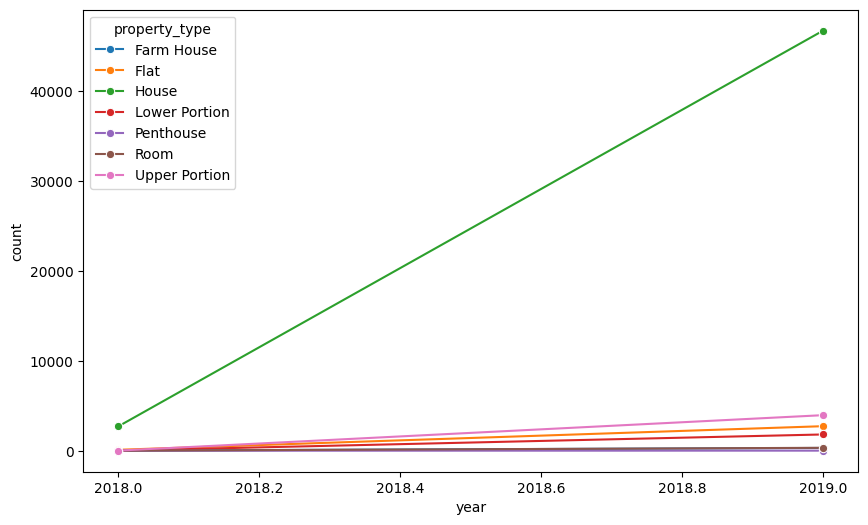

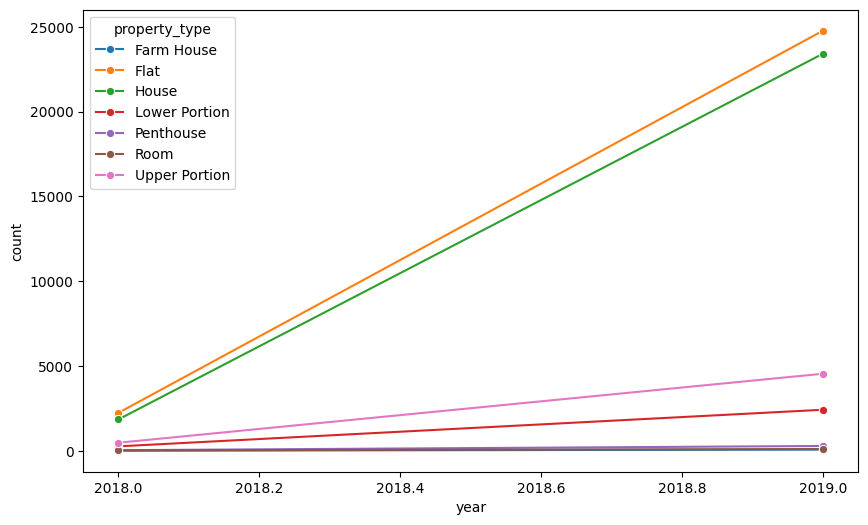

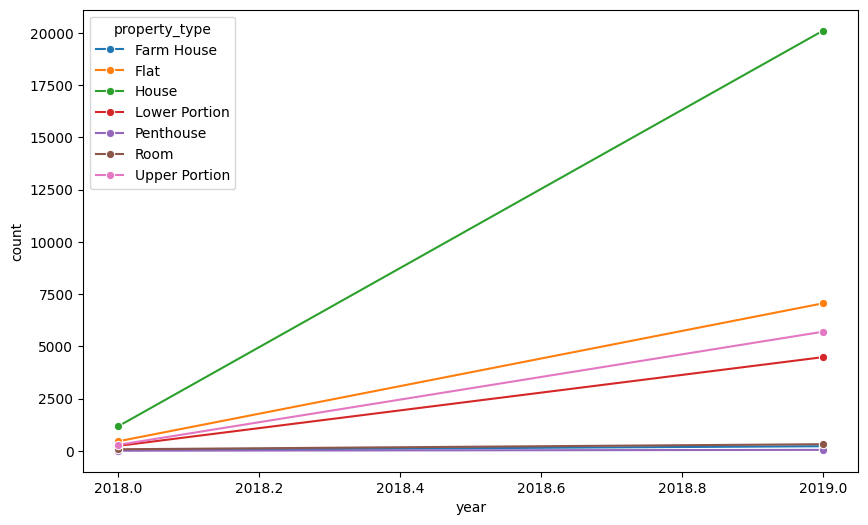

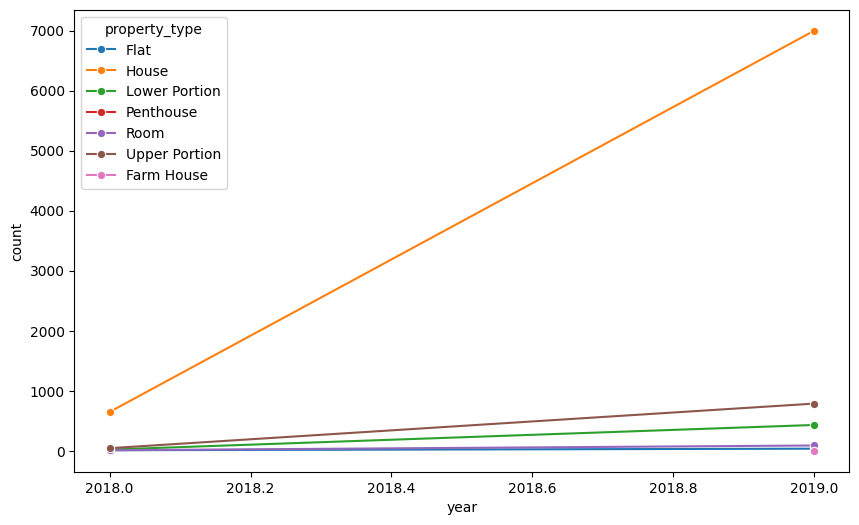

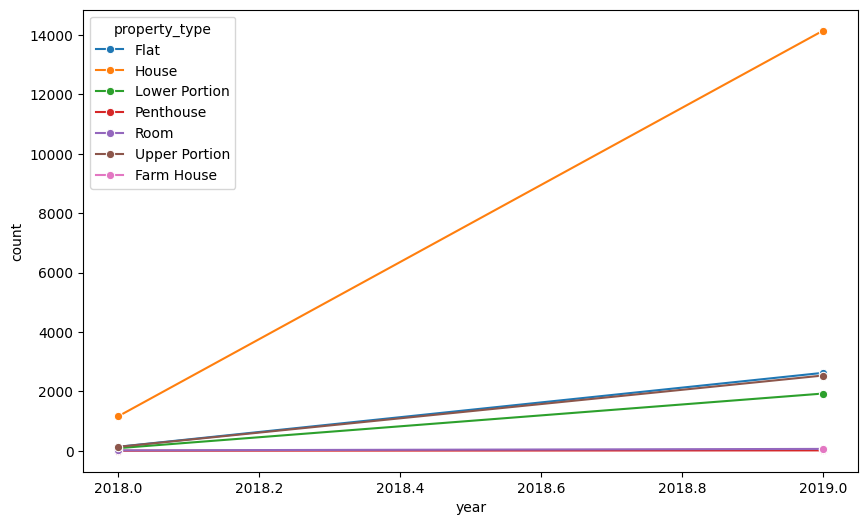

In [ ]:
cities = data['city'].unique()
for city in cities:
    city_data = city_year_type[city_year_type['city'] == city]
    plt.figure(figsize=(10,6))
    sns.lineplot(
        data=city_data,
        x='year',
        y='count',
        hue='property_type',
        marker='o'
    )

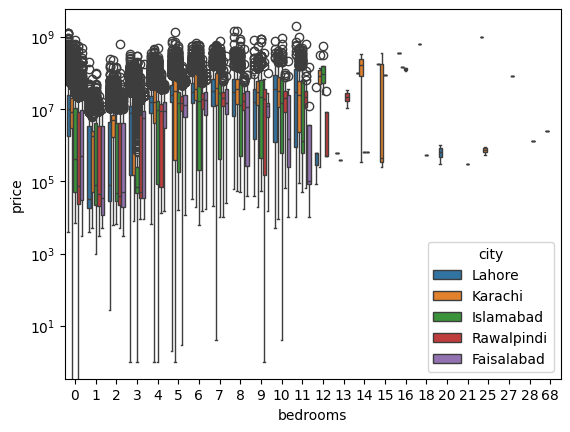

In [ ]:
sns.boxplot(
    data=data,
    x='bedrooms',
    y='price',
    hue='city'
)
plt.yscale('log')
plt.show()

In [ ]:
top_locations = data['location'].value_counts().head(10).index
high_demand_data = data[data['location'].isin(top_locations)]
agency_counts = high_demand_data['agency'].value_counts().head(10)
agency_counts


,count
agency,
Unknown,15338
Mash Allah Estate & Builders,821
Real Investment Consultants,792
Future Planners,541
Lahore Grande Estate,455
Arham Estate,429
Makkah Associates,409
WAG Estate & Construction,351
ZPN Real Estate & Builders,297


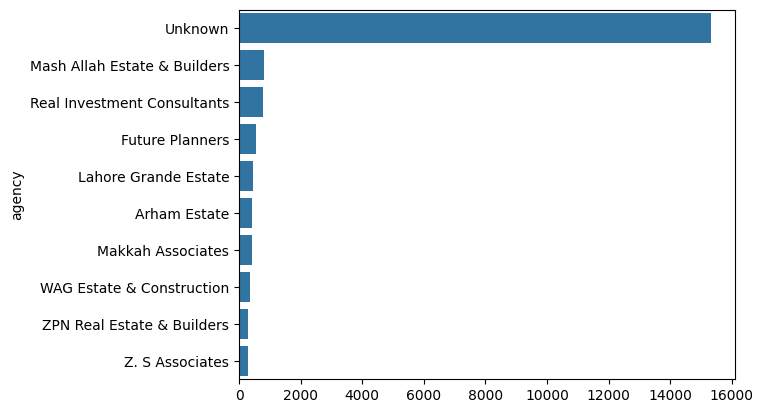

In [ ]:
sns.barplot(x=agency_counts.values, y=agency_counts.index)
plt.show()

In [ ]:
data['month'] = data['date_added'].dt.month
data['year'] = data['date_added'].dt.year
monthly_counts = data.groupby('month').size().reset_index(name='count')
monthly_counts

,month,count
0,1,4800
1,2,5440
2,3,6414
3,4,9641
4,5,14132
5,6,50566
6,7,88069
7,8,1871
8,9,2509
9,10,2706


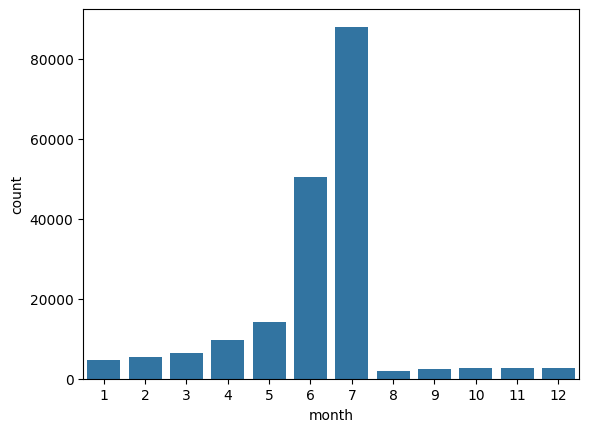

In [ ]:
sns.barplot(x='month', y='count', data=monthly_counts)
plt.show()

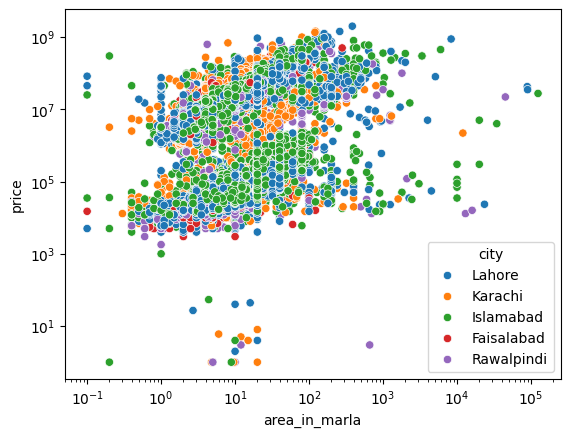

In [ ]:
sns.scatterplot(
    data=data,
    x='area_in_marla',
    y='price',
    hue='city',
)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
province_property_counts = data.groupby(['province_name', 'property_type']).size().reset_index(name='count')
province_property_counts.head()


,province_name,property_type,count
0,Islamabad Capital,Farm House,253
1,Islamabad Capital,Flat,7514
2,Islamabad Capital,House,21280
3,Islamabad Capital,Lower Portion,4720
4,Islamabad Capital,Penthouse,51


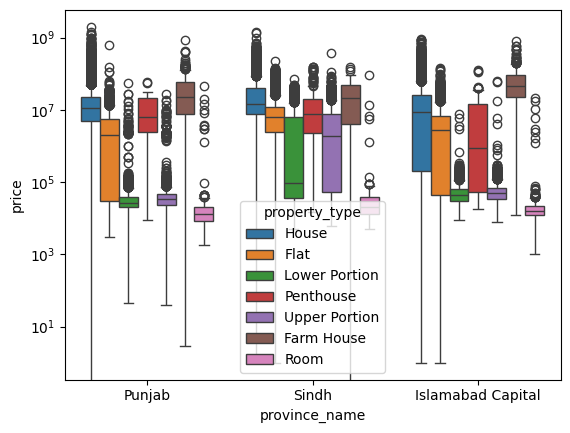

In [ ]:
sns.boxplot(
    data=data,
    x='province_name',
    y='price',
    hue='property_type'
)
plt.yscale('log')
plt.show()

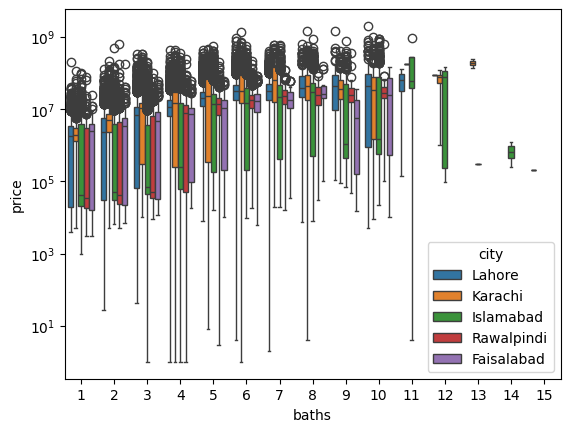

In [ ]:
data_clean = data[(data['baths'] >= 1) & (data['baths'] <= 15)]
sns.boxplot(
    data=data_clean,
    x='baths',
    y='price',
    hue='city'
)
plt.yscale('log')
plt.show()


In [ ]:
purpose_city_counts = data.groupby(['city','purpose']).size().reset_index(name='count')
purpose_city_counts.head()

,city,purpose,count
0,Faisalabad,For Rent,3888
1,Faisalabad,For Sale,5192
2,Islamabad,For Rent,22976
3,Islamabad,For Sale,17219
4,Karachi,For Rent,13815


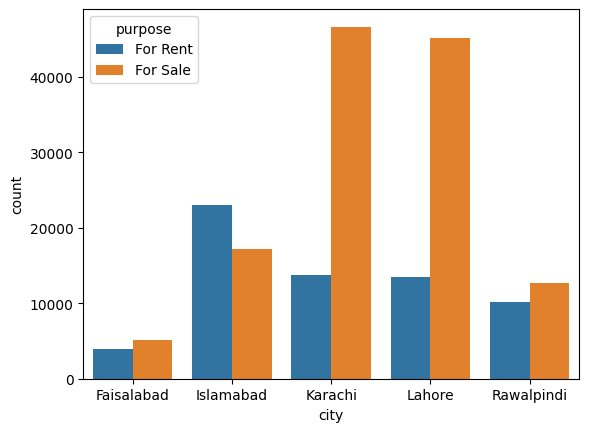

In [ ]:
sns.barplot(
    data=purpose_city_counts,
    x='city',
    y='count',
    hue='purpose')
plt.show()

In [ ]:
high_value_threshold = 50000000
high_value_props = data[data['price'] > high_value_threshold]
top_agents = high_value_props.groupby('agent').size().reset_index(name='count').sort_values(by='count', ascending=False)
top_agents.head(10)



,agent,count
2376,Unknown,2082
62,Abdul Latif Shah,138
494,Ch Muhammad Saeed,123
336,Asad Mirza,108
1956,S. Kazim Raza,91
584,Ehtisham,87
614,Fahad Memon,79
305,Aqib Hameed,77
1859,Rana Amjad,56
885,Irbaz S. Bajwa,55


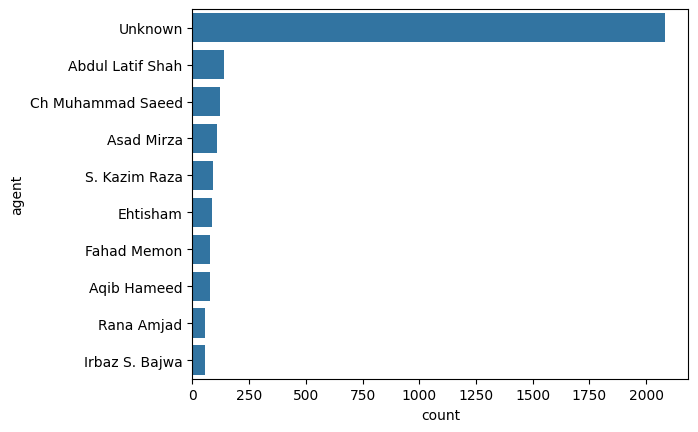

In [ ]:
sns.barplot(
    data=top_agents.head(10),
    x='count',
    y='agent')
plt.show()